# Weekly Challenge

In [3]:
!pip install torch scikit-learn numpy pandas

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

## 1. 가상 데이터셋을 생성한 뒤, 학습·검증·테스트 데이터셋으로 분할해 보세요.

In [11]:
from sklearn.model_selection import train_test_split

In [47]:
dummy_inps = np.random.rand(1000, 3, 224, 224) # 224x224 이미지 1000장

train_ratio = .8
val_ratio = .1
test_ratio = .1
train, eval = train_test_split(dummy_inps, train_size=train_ratio)
val, test = train_test_split(eval, test_size=.5)

train.shape, val.shape, test.shape

((800, 3, 224, 224), (100, 3, 224, 224), (100, 3, 224, 224))

## 2. 가상 데이터셋을 생성하고, K-최근접이웃(K-NN) 알고리즘으로 학습·예측을 수행해 보세요.

In [48]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

In [49]:
dummy_inps = np.random.randn(100, 1)
y = np.random.randint(low=0, high=2, size=(100, 1))

x_train, x_eval, y_train, y_eval = train_test_split(dummy_inps, y, train_size=train_ratio)
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_eval = scaler.transform(x_eval)

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train, y_train)
knn_model.predict(x_eval)

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


array([1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0])

## 3. 동일한 이진 분류 가상 데이터셋을 생성하고, Perceptron, SVM, Random Forest, Naive Bayes 네 가지 알고리즘으로 학습해 보세요.

In [50]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

### Perceptron

In [52]:
weights = np.random.rand(x_train.shape[-1])
bias = np.random.rand(x_train.shape[-1])
lr = 1e-3

print("학습 전")
print(f"weights: {weights}")
print(f"bias: {bias}")

def step_func(tensor: np.ndarray):
    return 1 if tensor >= np.zeros(tensor.shape) else 0

for i in range(len(x_train)):
    y_pred = np.dot(x_train[i], weights) + bias
    y_pred = step_func(y_pred)
    error = y_train[i] - y_pred
    weights += lr * error * x_train[i]
    bias += lr * error

print("학습 후")
print(f"weights: {weights}")
print(f"bias: {bias}")

학습 전
weights: [0.94993264]
bias: [0.07209651]
학습 후
weights: [0.92086827]
bias: [0.06609651]


### SVM

In [55]:
svm_model = SVC(kernel='linear')

svm_model.fit(x_train, y_train)
svm_model.predict(x_eval)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


array([0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1])

### Random Forest

In [56]:
rf_model = RandomForestClassifier()
rf_model.fit(x_train, y_train)
rf_model.predict(x_eval)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


array([0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0])

### Naive Bayes

In [57]:
nb_model = GaussianNB()

nb_model.fit(x_train, y_train)
nb_model.predict(x_eval)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


array([0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1])

## 4. 가상 데이터셋을 준비하고, 증강(Data Augmentation) 기법을 적용했을 때와 적용하지 않았을 때 모델 성능을 비교하세요.

## 5. 활성화 함수를 직접 정의하고, 활성화 함수를 적용한 출력을 계산하고, 결과를 그래프로 시각화하세요.

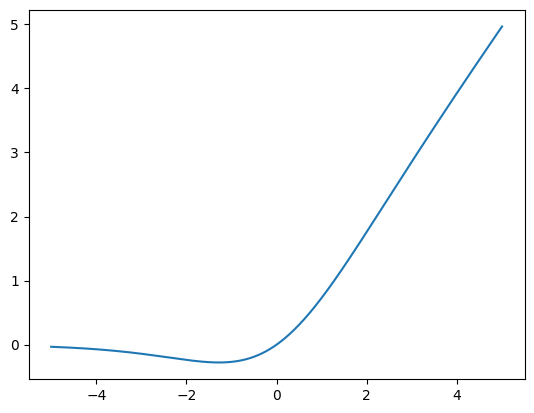

In [65]:
def SiLU(x: torch.Tensor):
    return x * (1 / (1 + torch.exp(-x)))

import matplotlib.pyplot as plt

x = torch.linspace(-5, 5, 1000)
plt.plot(x, SiLU(x))

plt.show()

## 6. 비선형 데이터셋을 생성하고, MLP(다층 퍼셉트론) 모델을 설계하고 학습시켜 분류를 수행하세요.


## 7. CNN(Convolutional Neural Network)을 직접 구성하여 이미지 분류를 수행하세요.